In [1]:
import os
import numpy as np 
import pandas as pd


import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler

In [2]:
data_dir = '/kaggle/input/chest_xray' 

train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, "val")


In [3]:
from torchvision import transforms

data_transform = {

    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),

    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


# Balancing train and val datasets

In [4]:
from torch.utils.data import random_split

# Let's have train + test folders
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transform['train'])


train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size


train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])  # random_split is a function from torch.utils.data that takes: 1. A dataset (like your custom dataset, ImageFolder, etc.) 2. Lengths of the splits you want (e.g., 80/20 or 70/20/10)


image_datasets = {
    'train': train_dataset,
    'val': val_dataset,
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=data_transform['test'])
}


dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

for x in ['train', 'val', 'test']:
    print("Loaded {} images under {}".format(dataset_sizes[x], x))


Loaded 4694 images under train
Loaded 522 images under val
Loaded 624 images under test


## Weighted Random Sampler
- fixes imbalanced classes by giving higher sampling probability to rare (minority) classes and lower to frequent (majority) ones.

- Class Balancing: WeightedRandomSampler ensures the model sees both NORMAL and PNEUMONIA equally

In [5]:
# Get all class indices (e.g., 0 for NORMAL, 1 for PNEUMONIA) . we are performing this operation to find count how many samples each class has, so that weights compute class weights
# note _ means “ignore this variable” (the file path). 

# Access underlying dataset from the Subset
train_dataset = image_datasets['train']

# The Subset stores the indices of samples from the original ImageFolder dataset
train_targets = [train_dataset.dataset.imgs[i][1] for i in train_dataset.indices]

# Convert to tensor 
train_targets = torch.tensor(train_targets)

# Count number of samples per class (e.g., 0 = NORMAL, 1 = PNEUMONIA)
class_counts = torch.bincount(train_targets)

# Compute class weights (inverse of counts)
class_weights = 1. / class_counts.float()

# Assign weight to each sample according to its class
sample_weights = [class_weights[label] for label in train_targets]

# Create sampler
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [11]:
# Training dataloader with weighted sampler for class imbalance
train_dataloader = torch.utils.data.DataLoader(
    image_datasets['train'],
    batch_size=32,
    sampler=sampler,                                        # Only use sampler for training
    num_workers=4
)

# Validation dataloader (no sampler, no shuffle needed)
val_dataloader = torch.utils.data.DataLoader(
    image_datasets['val'],
    batch_size=32,
    shuffle=False,                                          # Don't shuffle validation data
    num_workers=4
)

# Test dataloader (no sampler, no shuffle)
test_dataloader = torch.utils.data.DataLoader(
    image_datasets['test'],
    batch_size=32,
    shuffle=False,                                          # Don't shuffle test data
    num_workers=4
)

# Combine into dictionary
dataloader = {
    'train': train_dataloader,
    'val': val_dataloader,
    'test': test_dataloader
}


In [13]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
from torchvision import models
import torch.nn as nn

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Change last FC layer (for 2 classes)
num_classes = 2
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Move model to GPU/CPU
model = model.to(device)

print("Model loaded!")


Model loaded!


In [16]:
import torch.nn as nn
import torch.optim as optim

# Label smoothing helps generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW is usually better than Adam for vision models
learning_rate = 1e-4   # slightly higher than before since we use scheduler
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

num_epochs = 20  # You wanted 20 epochs

# Cosine annealing LR schedule over full training
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


In [17]:
scaler = torch.cuda.amp.GradScaler()


/tmp/ipykernel_39/2655216266.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [18]:
from tqdm import tqdm

def train_model(model, dataloader, criterion, optimizer, scheduler,
                num_epochs=20, best_model_path="resnet50_xray_best.pth"):
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            total = 0

            for inputs, labels in tqdm(dataloader[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    with torch.cuda.amp.autocast():   # AMP autocast
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)
                total += labels.size(0)

            epoch_loss = running_loss / total
            epoch_acc = running_corrects.float() / total

            print(f"{phase} Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

            # ✅ Save best model whenever validation accuracy improves
            if phase == "val":
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_path)
                    print(f"✅ New best model saved (val acc: {best_val_acc:.4f})")

        # step LR after each epoch
        scheduler.step()

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    # Load the best model weights before returning
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model
model = train_model(model, dataloader, criterion, optimizer, scheduler,
                    num_epochs=num_epochs, best_model_path="resnet50_xray_best.pth")



Epoch 1/20
--------------------


  0%|          | 0/147 [00:00<?, ?it/s]/tmp/ipykernel_39/1166565422.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # AMP autocast
100%|██████████| 147/147 [00:52<00:00,  2.79it/s]


train Loss: 0.3317, Acc: 0.9312


100%|██████████| 17/17 [00:05<00:00,  3.34it/s]


val Loss: 0.2654, Acc: 0.9636
✅ New best model saved (val acc: 0.9636)

Epoch 2/20
--------------------


...

val Loss: 0.2237, Acc: 0.9885

Epoch 20/20
--------------------


100%|██████████| 147/147 [00:51<00:00,  2.83it/s]


train Loss: 0.2031, Acc: 0.9991


100%|██████████| 17/17 [00:04<00:00,  3.77it/s]


val Loss: 0.2260, Acc: 0.9847

Best validation accuracy: 0.9923


In [19]:
# Load best model for testing
model.load_state_dict(torch.load("resnet50_xray_best.pth", map_location=device))
model.to(device)
model.eval()

print("Loaded best ResNet50 model for testing!")


Loaded best ResNet50 model for testing!


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def test_model(model, dataloader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = (all_preds == all_labels).mean()
    print(f"\n🔥 Test Accuracy: {accuracy * 100:.2f}%")

    cm = confusion_matrix(all_labels, all_preds)
    print("\n📌 Confusion Matrix:")
    print(cm)

    print("\n📌 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))
    
    return accuracy, cm

test_accuracy, cm = test_model(model, dataloader)



🔥 Test Accuracy: 95.03%

📌 Confusion Matrix:
[[208  26]
 [  5 385]]

📌 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.89      0.93       234
   PNEUMONIA       0.94      0.99      0.96       390

    accuracy                           0.95       624
   macro avg       0.96      0.94      0.95       624
weighted avg       0.95      0.95      0.95       624



Predicted Class: NORMAL
Probabilities: [0.955715   0.04428497]


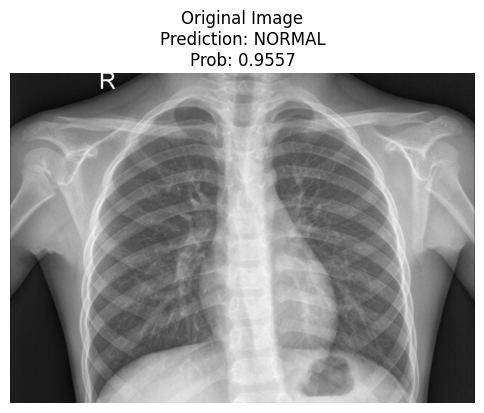

Predicted Class: PNEUMONIA
Probabilities: [0.01549415 0.98450583]


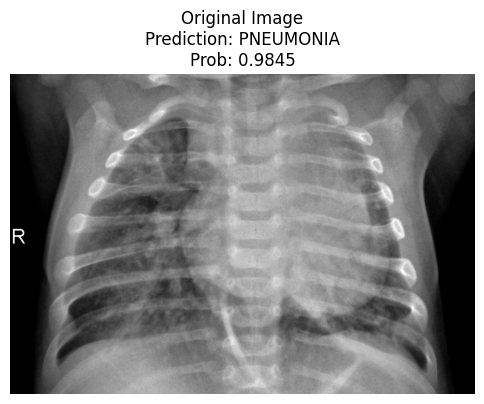

In [23]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

class_names = ["NORMAL", "PNEUMONIA"]  # make sure order matches your ImageFolder

def load_image(img_path):
    """
    Loads an image file and applies test transform.
    Returns:
        input_tensor: tensor of shape (1, C, H, W) on device
        img_np: numpy image in [0,1] for visualization
    """
    img = Image.open(img_path).convert("RGB")
    
    # For visualization later (unnormalized)
    img_np = np.array(img).astype(np.float32) / 255.0
    
    # Apply same transform as test
    input_tensor = data_transform['test'](img).unsqueeze(0).to(device)
    return input_tensor, img_np

def predict_single(input_tensor):
    """
    Returns predicted class index and softmax probabilities.
    """
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1)
        pred_class = probs.argmax(dim=1).item()
    return pred_class, probs.cpu().numpy()[0]

img_path = "/kaggle/input/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

 # img_path = /kaggle/input/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg
 # img_path = "/kaggle/input/chest_xray/test/NORMAL/IM-0001-0001.jpeg"
# /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg
# Load image
x, x_vis = load_image(img_path)

# Predict
pred_class, probs = predict_single(x)

# Print prediction info
print("Predicted Class:", class_names[pred_class])
print("Probabilities:", probs)

# Display original image
plt.figure(figsize=(6,6))
plt.imshow(x_vis)
plt.title(f"Original Image\nPrediction: {class_names[pred_class]}\nProb: {probs[pred_class]:.4f}")
plt.axis("off")
plt.show()
img_path = "/kaggle/input/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"

 # img_path = /kaggle/input/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg
 # img_path = "/kaggle/input/chest_xray/test/NORMAL/IM-0001-0001.jpeg"
# /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg
# Load image
x, x_vis = load_image(img_path)

# Predict
pred_class, probs = predict_single(x)

# Print prediction info
print("Predicted Class:", class_names[pred_class])
print("Probabilities:", probs)

# Display original image
plt.figure(figsize=(6,6))
plt.imshow(x_vis)
plt.title(f"Original Image\nPrediction: {class_names[pred_class]}\nProb: {probs[pred_class]:.4f}")
plt.axis("off")
plt.show()


In [84]:

!pip install grad-cam




ModuleNotFoundError: No module named 'grad_cam'

In [24]:
!pip install grad-cam

import torch
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target layer (last conv layer of ResNet50)
target_layers = [model.layer4[-1]]

# IMPORTANT: no use_cuda parameter in new version
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 72.0 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.2 MB/s eta 0:00:00:

In [ ]:
# def run_gradcam_pp(img_path, target_class=None):
#     input_tensor, img_vis = load_image(img_path)

#     pred_class, probs = predict_single(input_tensor)
#     if target_class is None:
#         target_class = pred_class

#     print(f"Target class: {class_names[target_class]} (index {target_class})")
#     print("Predicted probs:", probs)

#     targets = [ClassifierOutputTarget(target_class)]

#     grayscale_cam = cam(
#         input_tensor=input_tensor,
#         targets=targets
#     )[0]

#     cam_image = show_cam_on_image(img_vis, grayscale_cam, use_rgb=True)

#     plt.figure(figsize=(10,4))

#     plt.subplot(1,3,1)
#     plt.title("Original")
#     plt.axis("off")
#     plt.imshow(img_vis)

#     plt.subplot(1,3,2)
#     plt.title("Grad-CAM++")
#     plt.axis("off")
#     plt.imshow(grayscale_cam, cmap="jet")

#     plt.subplot(1,3,3)
#     plt.title("Overlay")
#     plt.axis("off")
#     plt.imshow(cam_image)

#     plt.show()


In [25]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def run_gradcam_pp(img_path, target_class=None):
    """
    img_path: path to chest X-ray
    target_class: int (0 = NORMAL, 1 = PNEUMONIA). If None, uses model prediction.
    """
    # Load image (your helper)
    input_tensor, img_vis = load_image(img_path)  # img_vis may be original size

    # Predict
    pred_class, probs = predict_single(input_tensor)
    if target_class is None:
        target_class = pred_class

    print(f"Target class: {class_names[target_class]} (index {target_class})")
    print("Predicted probs:", probs)

    # Grad-CAM++ targets
    targets = [ClassifierOutputTarget(target_class)]

    # Get CAM (H_cam, W_cam)
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]  # (H_cam, W_cam)

    # 🔧 Resize img_vis to match CAM size
    H_cam, W_cam = grayscale_cam.shape
    img_pil = Image.fromarray((img_vis * 255).astype(np.uint8))
    img_pil_resized = img_pil.resize((W_cam, H_cam))
    img_vis_resized = np.array(img_pil_resized).astype(np.float32) / 255.0  # (H_cam, W_cam, 3)

    # Overlay heatmap on resized image
    cam_image = show_cam_on_image(img_vis_resized, grayscale_cam, use_rgb=True)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original (resized)")
    plt.axis("off")
    plt.imshow(img_vis_resized)

    plt.subplot(1,3,2)
    plt.title("Grad-CAM++")
    plt.axis("off")
    plt.imshow(grayscale_cam, cmap="jet")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.axis("off")
    plt.imshow(cam_image)

    plt.show()


Target class: NORMAL (index 0)
Predicted probs: [0.955715   0.04428497]


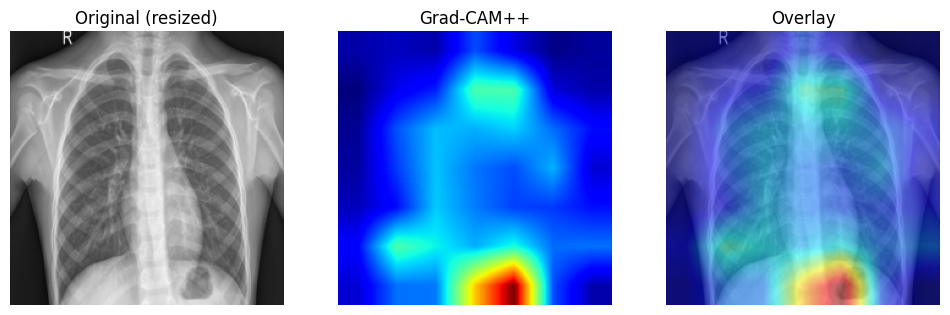

In [33]:
# run_gradcam_pp("/kaggle/input/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg")
run_gradcam_pp("/kaggle/input/chest_xray/test/NORMAL/IM-0001-0001.jpeg")


In [27]:
# LIME
!pip install lime

from lime import lime_image
from skimage.segmentation import mark_boundaries
import torch.nn.functional as F  # if not already imported


In [28]:
explainer = lime_image.LimeImageExplainer()

def lime_predict(images):
    """
    images: list/array of images, shape (N, H, W, 3), in [0,1] or [0,255]
    returns: (N, num_classes) probabilities
    """
    model.eval()
    batch_tensors = []

    for img in images:
        # ensure float32 [0,1]
        if img.max() > 1.0:
            img = img.astype(np.float32) / 255.0

        pil_img = Image.fromarray((img * 255).astype(np.uint8))
        tensor_img = data_transform['test'](pil_img)  # (C,H,W)
        batch_tensors.append(tensor_img)

    batch = torch.stack(batch_tensors).to(device)  # (N,C,H,W)

    with torch.no_grad():
        outputs = model(batch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()

    return probs


In [29]:
def run_lime(img_path, label=None):
    """
    img_path: path to image
    label: class index to explain (0 = NORMAL, 1 = PNEUMONIA). 
           If None, explains the predicted class.
    """
    # Original image for LIME (no transform)
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img).astype(np.float32) / 255.0  # (H,W,3)

    # Model prediction (using your helper)
    input_tensor, _ = load_image(img_path)
    pred_class, probs = predict_single(input_tensor)

    if label is None:
        label = pred_class

    print("Pred class:", class_names[pred_class], "Probs:", probs)
    print("Explaining class:", class_names[label])

    # Explain this instance
    explanation = explainer.explain_instance(
        img_np,
        lime_predict,
        top_labels=2,
        hide_color=0,
        num_samples=1000,   # more samples = smoother explanation but slower
    )

    # Get superpixels that positively contribute to 'label'
    temp, mask = explanation.get_image_and_mask(
        label,
        positive_only=True,
        num_features=5,    # number of important regions to show
        hide_rest=False
    )

    # Plot
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.axis("off")
    plt.imshow(img_np)

    plt.subplot(1,2,2)
    plt.title(f"LIME: important regions for {class_names[label]}")
    plt.axis("off")
    plt.imshow(mark_boundaries(temp/255.0, mask))

    plt.show()


Pred class: PNEUMONIA Probs: [0.01549415 0.98450583]
Explaining class: PNEUMONIA


  0%|          | 0/1000 [00:00<?, ?it/s]

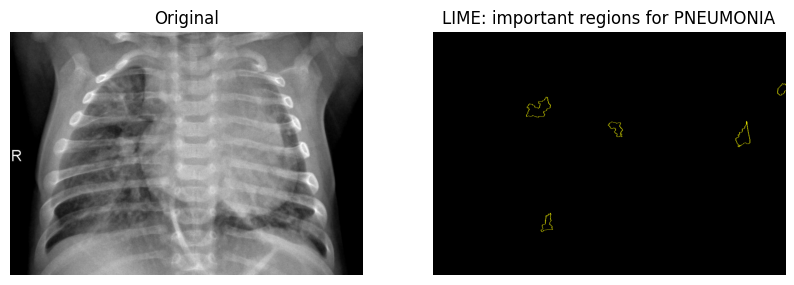

In [30]:
img_path = "/kaggle/input/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"
run_lime(img_path)


In [97]:
!pip install shap

import shap


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 83.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.0.2 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.0.2 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0

In [98]:
# Take a small batch from train loader as background
background_batch, _ = next(iter(train_dataloader))  # (B,C,H,W)
background = background_batch[:20].to(device)       # use first 20 as background

model.eval()
explainer = shap.GradientExplainer(model, background)


In [ ]:
def run_shap_on_image(img_path):
    # Prepare input tensor for the model
    input_tensor, img_vis = load_image(img_path)  # img_vis in [0,1], (H,W,3)
    input_tensor = input_tensor.to(device)        # (1,C,H,W)

    # Model prediction
    pred_class, probs = predict_single(input_tensor)
    print("Pred class:", class_names[pred_class], "Probs:", probs)

    # Compute SHAP values
    shap_values, indexes = explainer.shap_values(input_tensor)
    # shap_values can be:
    #  - list of length num_classes: [ (1,C,H,W), (1,C,H,W), ... ]
    #  - list of length 1: [ (1,C,H,W) ]

    # ---- pick the right tensor ----
    if isinstance(shap_values, list):
        if len(shap_values) == 1:
            # Only one attribution map returned → use that
            sv = shap_values[0][0]   # (C,H,W)
        else:
            # One map per class → pick predicted class
            sv = shap_values[pred_class][0]  # (C,H,W)
    else:
        # Rare case: shap_values is a single array
        sv = shap_values[0]

    # Ensure shape is (C,H,W)
    if sv.ndim == 4:      # e.g., (1,C,H,W)
        sv = sv[0]
    # Now sv should be (C,H,W) or (H,W,C)

    # Aggregate over channels to get 2D map
    if sv.shape[0] in [1, 3]:   # likely (C,H,W)
        sv_2d = sv.mean(axis=0)    # (H,W)
    else:                        # likely (H,W,C)
        sv_2d = sv.mean(axis=-1)   # (H,W)

    # Normalize for visualization
    sv_min, sv_max = sv_2d.min(), sv_2d.max()
    sv_norm = (sv_2d - sv_min) / (sv_max - sv_min + 1e-8)

    # Resize img_vis to SHAP map size if needed
    H_s, W_s = sv_norm.shape
    img_pil = Image.fromarray((img_vis * 255).astype(np.uint8))
    img_pil_resized = img_pil.resize((W_s, H_s))
    img_vis_resized = np.array(img_pil_resized).astype(np.float32) / 255.0

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original (resized)")
    plt.axis("off")
    plt.imshow(img_vis_resized)

    plt.subplot(1,3,2)
    plt.title("SHAP heatmap")
    plt.axis("off")
    plt.imshow(sv_norm, cmap="bwr")  # blue=negative, red=positive

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.axis("off")
    plt.imshow(img_vis_resized)
    plt.imshow(sv_norm, cmap="bwr", alpha=0.5)

    plt.show()


In [101]:
img_path = "/kaggle/input/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"
run_shap_on_image(img_path)


Pred class: PNEUMONIA Probs: [0.05953268 0.9404673 ]


IndexError: index 1 is out of bounds for axis 0 with size 1

In [32]:
# # new approach

# scaler = torch.cuda.amp.GradScaler()

# def train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=5):
#     best_val_acc = 0.0
#     best_weights = model.state_dict()

#     for epoch in range(num_epochs):
#         print(f"\nEpoch {epoch+1}/{num_epochs}")
#         print("-" * 20)

#         for phase in ["train", "val"]:
#             if phase == "train":
#                 model.train()
#             else:
#                 model.eval()

#             running_loss = 0.0
#             running_corrects = 0
#             total_samples = 0

#             for inputs, labels in tqdm(dataloader[phase]):
#                 inputs = inputs.to(device)
#                 labels = labels.to(device)

#                 optimizer.zero_grad()

#                 with torch.set_grad_enabled(phase == "train"):
#                     with torch.cuda.amp.autocast():
#                         outputs = model(inputs)
#                         loss = criterion(outputs, labels)

#                     _, preds = torch.max(outputs, 1)

#                     if phase == "train":
#                         scaler.scale(loss).backward()
#                         scaler.step(optimizer)
#                         scaler.update()

#                 running_loss += loss.item() * inputs.size(0)
#                 running_corrects += torch.sum(preds == labels.data)
#                 total_samples += labels.size(0)

#             epoch_loss = running_loss / total_samples
#             epoch_acc = running_corrects.float() / total_samples

#             print(f"{phase} Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

#             # Track the best val accuracy
#             if phase == "val" and epoch_acc > best_val_acc:
#                 best_val_acc = epoch_acc
#                 best_weights = model.state_dict()

#         if scheduler is not None:
#             scheduler.step()

#     print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
#     model.load_state_dict(best_weights)
#     return model

# # =========================================================
# # 7. Phase 1: Train only FC layer
# # =========================================================

# print("\n===== Phase 1: Train only FC layer =====")

# # Load pretrained ResNet50
# model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# # Replace last layer
# num_classes = 2
# in_features = model.fc.in_features
# model.fc = nn.Linear(in_features, num_classes)

# model = model.to(device)

# # Freeze all layers except fc
# for name, param in model.named_parameters():
#     if "fc" in name:
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# model = train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=5)

# # =========================================================
# # 8. Phase 2: Fine-tune layer4 + FC
# # =========================================================

# print("\n===== Phase 2: Fine-tune layer4 + FC =====")

# for name, param in model.named_parameters():
#     if name.startswith("layer4") or name.startswith("fc"):
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# model = train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=10)

# # Save fine-tuned model
# model_path = "resnet50_xray_finetuned.pth"
# torch.save(model.state_dict(), model_path)
# print(f"\nModel saved to: {model_path}")

# # =========================================================
# # 9. Test Evaluation
# # =========================================================

# def test_model(model, dataloader):
#     model.eval()
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for inputs, labels in dataloader["test"]:
#             inputs = inputs.to(device)
#             labels = labels.to(device)

#             outputs = model(inputs)
#             _, preds = torch.max(outputs, 1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())

#     all_preds = np.array(all_preds)
#     all_labels = np.array(all_labels)

#     accuracy = (all_preds == all_labels).mean()
#     print(f"\n🔥 Test Accuracy: {accuracy * 100:.2f}%")

#     cm = confusion_matrix(all_labels, all_preds)
#     print("\n📌 Confusion Matrix:")
#     print(cm)

#     print("\n📌 Classification Report:")
#     print(classification_report(all_labels, all_preds, target_names=class_names))

#     return accuracy, cm

# # Load best weights (already loaded, but for safety)
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.to(device)

# test_accuracy, cm = test_model(model, dataloader)

/tmp/ipykernel_39/1460608217.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



===== Phase 1: Train only FC layer =====

Epoch 1/5
--------------------


  0%|          | 0/147 [00:00<?, ?it/s]/tmp/ipykernel_39/1460608217.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 147/147 [00:37<00:00,  3.96it/s]


train Loss: 0.4154, Acc: 0.8383


100%|██████████| 17/17 [00:03<00:00,  4.49it/s]


...

100%|██████████| 147/147 [00:37<00:00,  3.95it/s]


train Loss: 0.2220, Acc: 0.9173


100%|██████████| 17/17 [00:03<00:00,  4.61it/s]


val Loss: 0.2095, Acc: 0.9138

Best Val Accuracy: 0.9291

Model saved to: resnet50_xray_finetuned.pth

🔥 Test Accuracy: 82.05%

📌 Confusion Matrix:
[[224  10]
 [102 288]]

📌 Classification Report:


NameError: name 'class_names' is not defined

In [14]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import models
# from tqdm import tqdm

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.backends.cudnn.benchmark = True

# # --------------------- #
# #   Load ResNet50       #
# # --------------------- #

# model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# # Replace last layer
# num_classes = 2
# in_features = model.fc.in_features
# model.fc = nn.Linear(in_features, num_classes)

# model = model.to(device)

# # --------------------- #
# #      Loss & Optim     #
# # --------------------- #

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# scaler = torch.cuda.amp.GradScaler()   # Mixed precision

# # --------------------- #
# #     Training Loop     #
# # --------------------- #

# def train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=10):
#     best_val_acc = 0.0
#     best_weights = model.state_dict()

#     for epoch in range(num_epochs):
#         print(f"\nEpoch {epoch+1}/{num_epochs}")
#         print("-" * 20)

#         for phase in ["train", "val"]:
#             if phase == "train":
#                 model.train()
#             else:
#                 model.eval()

#             running_loss = 0.0
#             running_corrects = 0
#             total = 0

#             for inputs, labels in tqdm(dataloader[phase]):
#                 inputs = inputs.to(device)
#                 labels = labels.to(device)

#                 optimizer.zero_grad()

#                 with torch.set_grad_enabled(phase == "train"):
#                     with torch.cuda.amp.autocast():   # AMP autocast
#                         outputs = model(inputs)
#                         loss = criterion(outputs, labels)

#                     _, preds = torch.max(outputs, 1)

#                     if phase == "train":
#                         scaler.scale(loss).backward()
#                         scaler.step(optimizer)
#                         scaler.update()

#                 running_loss += loss.item() * inputs.size(0)
#                 running_corrects += torch.sum(preds == labels)
#                 total += labels.size(0)

#             epoch_loss = running_loss / total
#             epoch_acc = running_corrects.float() / total

#             print(f"{phase} Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

#             if phase == "val" and epoch_acc > best_val_acc:
#                 best_val_acc = epoch_acc
#                 best_weights = model.state_dict()

#         scheduler.step()

#     print(f"\nBest validation accuracy: {best_val_acc:.4f}")
#     model.load_state_dict(best_weights)
#     return model


# # --------------------- #
# #     Train Model       #
# # --------------------- #

# model = train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=10)

# # --------------------- #
# #      Save Model       #
# # --------------------- #

# torch.save(model.state_dict(), "resnet50_xray_best.pth")
# print("Model saved!")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]
/tmp/ipykernel_39/3271487057.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()   # Mixed precision



Epoch 1/10
--------------------


  0%|          | 0/147 [00:00<?, ?it/s]/tmp/ipykernel_39/3271487057.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # AMP autocast
100%|██████████| 147/147 [00:41<00:00,  3.50it/s]


train Loss: 0.5555, Acc: 0.7904


100%|██████████| 17/17 [00:03<00:00,  4.27it/s]


...

val Loss: 0.1783, Acc: 0.9406

Epoch 10/10
--------------------


100%|██████████| 147/147 [00:37<00:00,  3.92it/s]


train Loss: 0.2142, Acc: 0.9256


100%|██████████| 17/17 [00:03<00:00,  4.93it/s]


val Loss: 0.2217, Acc: 0.9157

Best validation accuracy: 0.9406
Model saved!


In [16]:
# # Load Best Model for Testing
# # Load best model (make sure path is correct)
# model.load_state_dict(torch.load("resnet50_xray_best.pth", map_location=device))
# model.to(device)
# model.eval()

# print("Loaded best ResNet50 model for testing!")



Loaded best ResNet50 model for testing!


In [19]:
# # 2. Test Evaluation Function (Accuracy, Confusion Matrix)
# from sklearn.metrics import confusion_matrix, classification_report
# import numpy as np

# def test_model(model, dataloader):
#     model.eval()
    
#     all_preds = []
#     all_labels = []
    
#     with torch.no_grad():
#         for inputs, labels in dataloader['test']:
#             inputs = inputs.to(device)
#             labels = labels.to(device)
            
#             outputs = model(inputs)
#             _, preds = torch.max(outputs, 1)
            
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
    
#     # Convert to numpy arrays
#     all_preds = np.array(all_preds)
#     all_labels = np.array(all_labels)
    
#     # Accuracy
#     accuracy = (all_preds == all_labels).mean()
#     print(f"\n🔥 Test Accuracy: {accuracy * 100:.2f}%")

#     # Confusion Matrix
#     cm = confusion_matrix(all_labels, all_preds)
#     print("\n📌 Confusion Matrix:")
#     print(cm)

#     # Classification Report (Precision, Recall, F1-score)
#     print("\n📌 Classification Report:")
#     print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))
    
#     return accuracy, cm
# test_accuracy, cm = test_model(model, dataloader)



🔥 Test Accuracy: 87.82%

📌 Confusion Matrix:
[[205  29]
 [ 47 343]]

📌 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.81      0.88      0.84       234
   PNEUMONIA       0.92      0.88      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.88      0.87       624
weighted avg       0.88      0.88      0.88       624



In [33]:
# from torchvision import models
# import torch.nn as nn
# import torch.optim as optim

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.backends.cudnn.benchmark = True

# # 1. Load pretrained ResNet50
# model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# num_classes = 2
# in_features = model.fc.in_features
# model.fc = nn.Linear(in_features, num_classes)
# model = model.to(device)

# # 2. Freeze all layers except fc
# for name, param in model.named_parameters():
#     if "fc" in name:
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
# scaler = torch.cuda.amp.GradScaler()


/tmp/ipykernel_39/1550804635.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [34]:
# model = train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=5)



Epoch 1/5
--------------------


  0%|          | 0/147 [00:00<?, ?it/s]/tmp/ipykernel_39/1460608217.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 147/147 [00:37<00:00,  3.91it/s]


train Loss: 0.4184, Acc: 0.8298


100%|██████████| 17/17 [00:03<00:00,  4.46it/s]


val Loss: 0.3702, Acc: 0.8525

Epoch 2/5
--------------------


...

val Loss: 0.2347, Acc: 0.9100

Epoch 5/5
--------------------


100%|██████████| 147/147 [00:36<00:00,  4.00it/s]


train Loss: 0.2820, Acc: 0.8901


100%|██████████| 17/17 [00:03<00:00,  4.50it/s]

val Loss: 0.2314, Acc: 0.9061

Best Val Accuracy: 0.9100


In [35]:
# Unfreeze layer4 and fc for fine-tuning
for name, param in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

# New optimizer and scheduler for fine-tuning
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
scaler = torch.cuda.amp.GradScaler()

# Fine-tune for more epochs
model = train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=10)

# Save best model
torch.save(model.state_dict(), "resnet50_xray_finetuned.pth")
print("Fine-tuned model saved!")


/tmp/ipykernel_39/2792470825.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Epoch 1/10
--------------------


  0%|          | 0/147 [00:00<?, ?it/s]/tmp/ipykernel_39/1460608217.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 147/147 [00:37<00:00,  3.92it/s]


train Loss: 0.2635, Acc: 0.8933


100%|██████████| 17/17 [00:03<00:00,  4.43it/s]


...

val Loss: 0.1869, Acc: 0.9310

Epoch 10/10
--------------------


100%|██████████| 147/147 [00:37<00:00,  3.88it/s]


train Loss: 0.2390, Acc: 0.9090


100%|██████████| 17/17 [00:03<00:00,  4.36it/s]


val Loss: 0.1889, Acc: 0.9349

Best Val Accuracy: 0.9387
Fine-tuned model saved!


In [37]:
# Load Best Model for Testing
# Load best model (make sure path is correct)
model.load_state_dict(torch.load("resnet50_xray_finetuned.pth", map_location=device))
model.to(device)
model.eval()

print("Loaded best ResNet50 model for testing!")



Loaded best ResNet50 model for testing!


In [38]:
# 2. Test Evaluation Function (Accuracy, Confusion Matrix)
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def test_model(model, dataloader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Accuracy
    accuracy = (all_preds == all_labels).mean()
    print(f"\n🔥 Test Accuracy: {accuracy * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\n📌 Confusion Matrix:")
    print(cm)

    # Classification Report (Precision, Recall, F1-score)
    print("\n📌 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))
    
    return accuracy, cm
test_accuracy, cm = test_model(model, dataloader)



🔥 Test Accuracy: 81.89%

📌 Confusion Matrix:
[[225   9]
 [104 286]]

📌 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.68      0.96      0.80       234
   PNEUMONIA       0.97      0.73      0.84       390

    accuracy                           0.82       624
   macro avg       0.83      0.85      0.82       624
weighted avg       0.86      0.82      0.82       624



In [ ]:
vgg16 = models.vgg16_bn(pretrained=True)       # VGG16 architecture that includes Batch Normalization (BN) layers.
vgg16

## Custome Classifier (FC layer)  

In [ ]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),                   # input = 512*7*7
    nn.ReLU(),
    nn.Dropout(0.3),                         # 0.5

    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 2)                         # 2 classes: NORMAL, PNEUMONIA
)

In [ ]:
for param in vgg16.features[-5:].parameters():
    param.requires_grad = True

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

In [ ]:
vgg16 = vgg16.to(device)

# Setup optimizer and loss
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)

# optimizer = optim.Adam(vgg16.classifier.parameters(), lr=0.001)
optimizer = torch.optim.Adam(vgg16.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


## How training loop works (Example)

loss.backward()  # ⭐ THE MAGIC HAPPENS HERE


### What `backward()` does:
1. Calculates gradients for EVERY parameter in the model
2. Gradient = "How much does changing this weight affect the loss?"
3. Uses chain rule (calculus) to propagate error backwards through layers

#### Conceptual Example:

Loss = 0.8 (too high!)
↓
Output Layer: "Weight W1 contributed +0.3 to the error"
↓  
Hidden Layer: "Weight W2 contributed +0.15 to the error"
↓
Input Layer: "Weight W3 contributed +0.05 to the error"

Gradients stored: W1.grad = 0.3, W2.grad = 0.15, W3.grad = 0.05


#### update weights 

optimizer.step()  # Updates all weights using their gradients

**How weights are updated (Gradient Descent):

new_weight = old_weight - (learning_rate × gradient)

Example:

W1 = 0.5 - (0.001 × 0.3) = 0.4997  # Slightly adjusted

In [ ]:

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Args:
        model: PyTorch model
        dataloader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer
        device: Device (CPU/GPU)
    
    Returns:
        avg_loss: Average loss for the epoch
        avg_acc: Average accuracy for the epoch
    """
    
    model.train()                      # enable dropout + batchnorm updates
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for inputs, labels in dataloader:          # load data in batches 
        inputs = inputs.to(device) 
        labels = labels.to(device)
        
        optimizer.zero_grad()

        
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)                  
        loss = criterion(outputs, labels)                     # return average loss per batch i.e loss = tensor(1.5432, grad_fn=<NllLossBackward>) where predicted class labels and correct class labels are compareed based on which averge batch loss is calculated

        
        # Backward pass
        loss.backward()                                         # Go through the entire model, compute the gradient (partial derivative) of the loss with respect to each parameter.
        optimizer.step()                                      # Use the gradients to update the model parameters weights

        
        # Accumulate metrics
        total_loss += loss.item() * inputs.size(0)            # average batch loss * the number of inputs in batch
        total_correct += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

    
    avg_loss = total_loss / total_samples
    avg_acc = total_correct.double().item() / total_samples
    
    return avg_loss, avg_acc

In [ ]:
    
def validate(model, dataloader, criterion, device):
    
    """
    Validate the model.
    
    Args:
        model: PyTorch model
        dataloader: DataLoader for validation data
        criterion: Loss function
        device: Device (CPU/GPU)
    
    Returns:
        avg_loss: Average validation loss
        avg_acc: Average validation accuracy
    """
    
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Forward pass only
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            # Accumulate metrics
            total_loss += loss.item() * inputs.size(0)
            total_correct += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
    
    avg_loss = total_loss / total_samples
    avg_acc = total_correct.double().item() / total_samples

    
    return avg_loss, avg_acc

In [ ]:
def save_checkpoint(model, filepath, accuracy):
    """
    Save model checkpoint.
    
    Args:
        model: PyTorch model
        filepath: Path to save the model
        accuracy: Current accuracy (for logging)
    """
    
    torch.save(model.state_dict(), filepath)
    print(f"💾 Model saved to {filepath} | Accuracy: {accuracy:.4f}")

In [ ]:

def train_model(model, dataloaders, criterion, optimizer, device, 
                epochs=10, save_best_path="best_model.pth", 
                save_final_path="final_model.pth"):
    """
    Complete training pipeline.
    
    Args:
        model: PyTorch model
        dataloaders: Dict with 'train' and 'val' DataLoaders
        criterion: Loss function
        optimizer: Optimizer
        device: Device (CPU/GPU)
        epochs: Number of training epochs
        save_best_path: Path to save best model
        save_final_path: Path to save final model
    
    Returns:
        best_acc: Best validation accuracy achieved
    """
    best_acc = 0.0
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 15)
        
        # Training phase
        train_loss, train_acc = train_one_epoch(
            model, dataloaders['train'], criterion, optimizer, device
        )
        print(f"Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
        
        # Validation phase
        val_loss, val_acc = validate(
            model, dataloaders['val'], criterion, device
        )
        print(f"Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            save_checkpoint(model, save_best_path, best_acc)
    
    # Save final model
    save_checkpoint(model, save_final_path, val_acc)
    print(f"\n🏁 Training complete! Best validation accuracy: {best_acc:.4f}")
    
    return best_acc

In [ ]:

if __name__ == "__main__":
    # Assuming you have these defined:
    # - vgg16: your model
    # - dataloader: dict with 'train' and 'val' keys
    # - criterion: loss function
    # - optimizer: optimizer
    # - device: torch.device
    
    best_accuracy = train_model(
        model=vgg16,
        dataloaders=dataloader,  # {'train': train_loader, 'val': val_loader}
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        save_best_path="best_vgg16_chest_xray.pth",
        save_final_path="final_vgg16_chest_xray.pth"
    )